# Week 4 Day 4 Lab


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

### Problem 1
1. Pick a dataset you have not used yet from our collection of datasets: [click here for link](https://github.com/garrett-kepler/Math-300----Mathematical-Computing/tree/main/Datasets).
2. Load the dataset into your notebook
3. Plot a feature of the dataset against another feature.
4. Does there seem to be a relationship?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
sns.set(style="whitegrid")
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df.head()

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


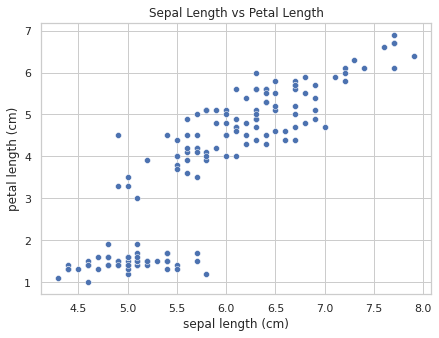

In [2]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="petal length (cm)"
)

plt.title("Sepal Length vs Petal Length")
plt.show()

There does seem to be a relationship, when the sepal lengths are shorter so is the petal length, vise versa

### Problem 2
1. Compute the correlation between all the features.
2. What is the largest correlated/anti-correlated features?
3. Do you have an explanation for why?

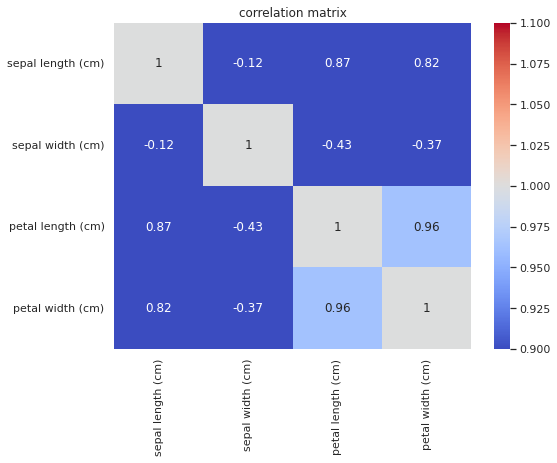

In [8]:
correlation=df.corr()
correlation
plt.figure(figsize=(8,6))
sns.heatmap(
    correlation, 
    annot=True,
    cmap="coolwarm",
    vmin=1,
    vmax=1,
)
plt.title("correlation matrix")
plt.show()

In [9]:
#2
corr_matrix = correlation.copy()
for i in range(len(corr_matrix)):
    corr_matrix.iloc[i, i] = 0
max_corr = corr_matrix.unstack().idxmax()
max_value = corr_matrix.unstack().max()
min_corr = corr_matrix.unstack().idxmin()
min_value = corr_matrix.unstack().min()
print("Largest Positive Correlation:")
print(max_corr, max_value)
print("\nLargest Negative Correlation:")
print(min_corr, min_value)

Largest Positive Correlation:
('petal length (cm)', 'petal width (cm)') 0.962865431402796

Largest Negative Correlation:
('sepal width (cm)', 'petal length (cm)') -0.42844010433053864


Logically it makes sense that the petal length and width grow together, however im unsure why there is a negative correlation

### Problem 3
Create one dataset with a strong positive correlation and another with a strong negative correlation. Plot them side by side and compare their correlation coefficients.

In [ ]:
import numpy as np
np.random.seed(42)
x = np.arange(1, 51)
y_positive = 2*x + np.random.normal(0, 5, len(x))
positive_df = pd.DataFrame({
    "x": x,
    "y": y_positive
})